In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes scikit-learn
!pip install -U fsspec==2025.3.2




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import necessery libraries


In [9]:
# %% Cell 2: Imports & Setup
import os, random
import torch, numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer, TrainingArguments, default_data_collator,
    BitsAndBytesConfig      #quant config
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ["WANDB_DISABLED"] = "true"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## Load the data and prepare descriptions

In [10]:
import pandas as pd, json
from sklearn.model_selection import train_test_split

df = pd.read_csv("mushrooms_1.csv")
df["class_label"] = df["class"].map({"e":"edible","p":"poisonous"})

def describe(r):
    return "; ".join(f"{c}: {r[c]}" for c in df.columns if c not in ["class","class_label"])

records = []
for _, r in df.iterrows():
    records.append({
      "instruction":"Classify this mushroom as edible or poisonous.",
      "input": describe(r),
      "output": r["class_label"]
    })

train, test = train_test_split(records, test_size=0.2, random_state=SEED)
for name, split in [("train",train),("test",test)]:
    with open(f"{name}.jsonl","w") as f:
        for rec in (train if name=="train" else test):
            f.write(json.dumps(rec)+"\n")
print(" JSONL created")

 JSONL created


## tokenization and datasets

In [11]:
# Tokenization & Datasets (2.1, 2.3)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def preprocess(ex):
    txt = ex["instruction"] + "\n" + ex["input"]
    tok = tokenizer(txt, truncation=True, padding="max_length", max_length=256)
    tok["labels"] = 0 if ex["output"]=="edible" else 1
    return tok

ds = load_dataset("json", data_files={"train":"train.jsonl","test":"test.jsonl"})
tokenized = ds.map(preprocess, batched=False)
tokenized.set_format("torch", columns=["input_ids","attention_mask","labels"])


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/6499 [00:00<?, ? examples/s]

Map:   0%|          | 0/1625 [00:00<?, ? examples/s]

## quantization and lora config

In [12]:
# Quant & LoRA Configs (2.2)
from bitsandbytes.nn import Params4bit
from transformers import BitsAndBytesConfig

#debug



bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    quantization_map={
        ".*\\.lora_.*": {"Linear": {"is_quantized": False}},
        ".*":          {"Linear": {"is_quantized": True}}
    }
)


lora_cfg = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["c_attn","c_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)







## training function

In [29]:
def train_model(model_name, tokenized, style):
    # 0) Tokenizer setup
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if "gpt2" in model_name:
        tokenizer.pad_token = tokenizer.eos_token

    # 1) Load model (FP16-only for encoder, 4-bit for decoder)
    if "distilbert" in model_name:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            torch_dtype=torch.float16
        )
    else:  # assume GPT2-style
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            quantization_config=bnb_cfg,  # 4-bit only here
            device_map="auto",
            torch_dtype=torch.float16
        )
        model.config.pad_token_id = tokenizer.pad_token_id

    model.to(device)

    # 2) Prepare + wrap with LoRA (correct layers per model)
    if "distilbert" in model_name:
        lora_cfg.target_modules = ["q_lin","v_lin"]
    else:
        lora_cfg.target_modules = ["c_attn","c_proj"]

    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_cfg)

    # 3) Label metadata
    model.config.id2label    = {0: "edible",    1: "poisonous"}
    model.config.label2id    = {"edible": 0,   "poisonous": 1}
    model.config.label_names = ["labels"]

    # 4) Trainer setup
    def compute_metrics(p):
        preds = p.predictions.argmax(-1)
        pr, rc, f1, _ = precision_recall_fscore_support(
            p.label_ids, preds, average="binary", zero_division=0
        )
        acc = accuracy_score(p.label_ids, preds)
        return {"accuracy": acc, "precision": pr, "recall": rc, "f1": f1}

    args = TrainingArguments(
        output_dir=f"results_{style}",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=4,
        learning_rate=2e-5,
        fp16=True,
        logging_steps=50,
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tokenizer,
        data_collator=default_data_collator,
        compute_metrics=compute_metrics
    )

    # 5) Train & return
    trainer.train()
    return trainer


## run training

In [30]:
# Encoder-only experiment (FP16)
bert_trainer = train_model("distilbert-base-uncased", tokenized, "distilbert")
print("DistilBERT + LoRA complete\n")

# Decoder-style experiment (4-bit)
gpt2_trainer = train_model("distilgpt2", tokenized, "distilgpt2")
print("DistilGPT2 + LoRA complete\n")


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:79: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'distilgpt2' to 'distilbert-base-uncased'. Please ensure that the correct base model is loaded when loading this checkpoint.
  warnings.warn(
<ipython-input-29-cb5bfe3c0e2d>:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can

Step,Training Loss
50,0.696900
100,0.693700
150,0.695600
200,0.691600
250,0.688900
300,0.688500
350,0.691400
400,0.694900
450,0.689400
500,0.692000


DistilBERT + LoRA complete



Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at distilgpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:79: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'distilbert-base-uncased' to 'distilgpt2'. Please ensure that the correct base model is loaded when loading this checkpoint.
  warnings.warn(
<ipython-input-29-cb5bfe3c0e2d>:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used ins

Step,Training Loss
50,2.233200
100,1.115500
150,0.867800
200,0.761700
250,0.752300
300,0.704100
350,0.700300
400,0.682500
450,0.644400
500,0.625100


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/

DistilGPT2 + LoRA complete



In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Choose which model to run inference on:
#   for DistilBERT: trainer = bert_trainer
#   for DistilGPT2: trainer = gpt2_trainer
trainer = gpt2_trainer
tokenizer = trainer.tokenizer
model     = trainer.model
model.to(device)
model.eval()

examples = [
    {
      "instruction": "Classify this mushroom as edible or poisonous.",
      "input": "cap-shape: convex; cap-surface: smooth; odor: foul"
    },
    {
      "instruction": "Classify this mushroom as edible or poisonous.",
      "input": "cap-shape: bell; cap-surface: scaly; odor: almond"
    }
]

for ex in examples:
    text = ex["instruction"] + "\n" + ex["input"]
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=256
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs  = torch.softmax(logits, dim=-1).squeeze().cpu().tolist()
        pred_id = int(torch.argmax(logits, dim=-1))
        label   = model.config.id2label[pred_id]
    print(f"\nInput:\n{text}\n→ Predicted: {label} (score {probs[pred_id]:.2f})")

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.



Input:
Classify this mushroom as edible or poisonous.
cap-shape: convex; cap-surface: smooth; odor: foul
→ Predicted: edible (score 0.95)

Input:
Classify this mushroom as edible or poisonous.
cap-shape: bell; cap-surface: scaly; odor: almond
→ Predicted: edible (score 0.97)


##  Evaluation and Save the modrl

=== DistilBERT + LoRA Evaluation ===


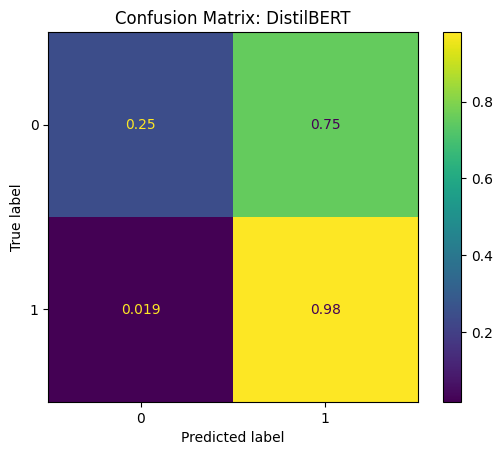

Accuracy:  59.9%
Precision: 54.7%
Recall:    98.1%
F1:        70.2%


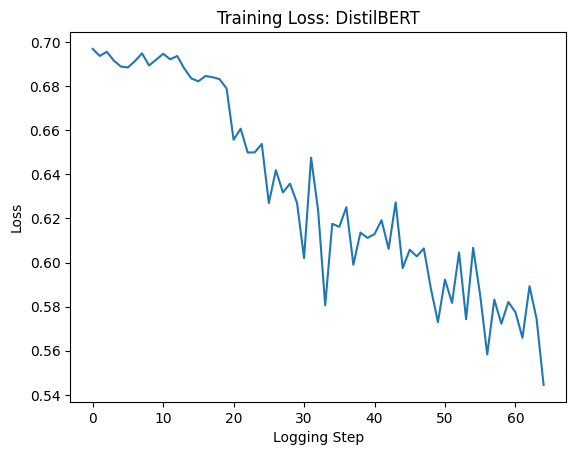

You are using a model of type gpt2 to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:250: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Saved DistilBERT model & tokenizer to ./distilbert_lora_finetuned/

=== DistilGPT2 + LoRA Evaluation ===


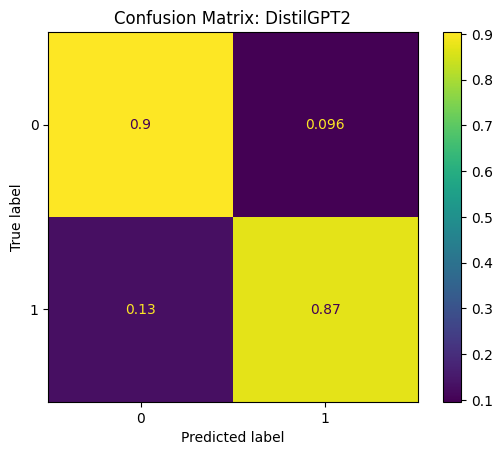

Accuracy:  88.8%
Precision: 89.4%
Recall:    87.1%
F1:        88.2%


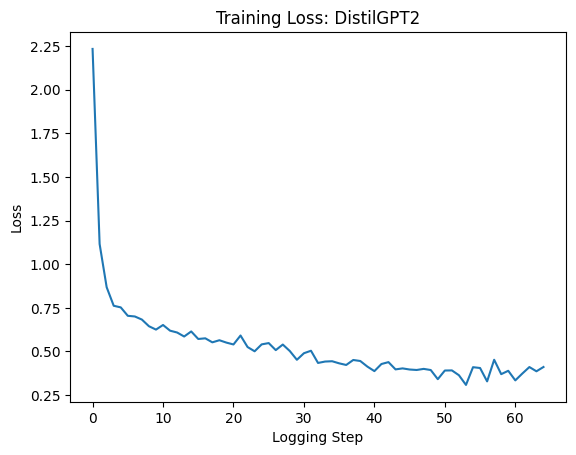

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Saved DistilGPT2 model & tokenizer to ./distilgpt2_lora_finetuned/


In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ─── Evaluation & Saving for DistilBERT + LoRA ─────────────────────────
print("=== DistilBERT + LoRA Evaluation ===")

# 1) Confusion matrix
bert_preds = bert_trainer.predict(tokenized["test"]).predictions.argmax(-1)
ConfusionMatrixDisplay.from_predictions(
    tokenized["test"]["labels"],
    bert_preds,
    normalize="true"
)
plt.title("Confusion Matrix: DistilBERT")
plt.show()

# 2) Scalar metrics
bert_eval = bert_trainer.evaluate()
print(f"Accuracy:  {bert_eval['eval_accuracy'] * 100:.1f}%")
print(f"Precision: {bert_eval['eval_precision'] * 100:.1f}%")
print(f"Recall:    {bert_eval['eval_recall'] * 100:.1f}%")
print(f"F1:        {bert_eval['eval_f1'] * 100:.1f}%")

# 3) Training loss plot
bert_losses = [log["loss"] for log in bert_trainer.state.log_history if "loss" in log]
plt.figure()
plt.plot(bert_losses)
plt.title("Training Loss: DistilBERT")
plt.xlabel("Logging Step")
plt.ylabel("Loss")
plt.show()

# 4) Save encoder checkpoint
output_dir_bert = "distilbert_lora_finetuned"
bert_trainer.model.save_pretrained(output_dir_bert)
bert_trainer.tokenizer.save_pretrained(output_dir_bert)
print(f"Saved DistilBERT model & tokenizer to ./{output_dir_bert}/\n")


# ─── Evaluation & Saving for DistilGPT2 + LoRA ─────────────────────────
print("=== DistilGPT2 + LoRA Evaluation ===")

# 1) Confusion matrix
gpt2_preds = gpt2_trainer.predict(tokenized["test"]).predictions.argmax(-1)
ConfusionMatrixDisplay.from_predictions(
    tokenized["test"]["labels"],
    gpt2_preds,
    normalize="true"
)
plt.title("Confusion Matrix: DistilGPT2")
plt.show()

# 2) Scalar metrics
gpt2_eval = gpt2_trainer.evaluate()
print(f"Accuracy:  {gpt2_eval['eval_accuracy'] * 100:.1f}%")
print(f"Precision: {gpt2_eval['eval_precision'] * 100:.1f}%")
print(f"Recall:    {gpt2_eval['eval_recall'] * 100:.1f}%")
print(f"F1:        {gpt2_eval['eval_f1'] * 100:.1f}%")

# 3) Training loss plot
gpt2_losses = [log["loss"] for log in gpt2_trainer.state.log_history if "loss" in log]
plt.figure()
plt.plot(gpt2_losses)
plt.title("Training Loss: DistilGPT2")
plt.xlabel("Logging Step")
plt.ylabel("Loss")
plt.show()

# 4) Save decoder checkpoint
output_dir_gpt2 = "distilgpt2_lora_finetuned"
gpt2_trainer.model.save_pretrained(output_dir_gpt2)
gpt2_trainer.tokenizer.save_pretrained(output_dir_gpt2)
print(f"Saved DistilGPT2 model & tokenizer to ./{output_dir_gpt2}/")
